In [4]:
## Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_log_error
import optuna

In [10]:
from scipy.stats import pointbiserialr

In [2]:
%pip install xgboost


  Using cached xgboost-3.0.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.0.0-py3-none-win_amd64.whl (150.0 MB)


In [5]:
import xgboost as xgb

In [6]:
## Path

path  = 'data/'

In [7]:
## Data

train = pd.read_csv(path + 'train.csv')

test = pd.read_csv(path + 'test.csv')

In [13]:
## Data Preprocessing

train['BMI'] = train['Weight'] / ((train['Height'] / 100) ** 2)

train['Sex_Encoded'] = train['Sex'].map({'male': 0, 'female': 1})

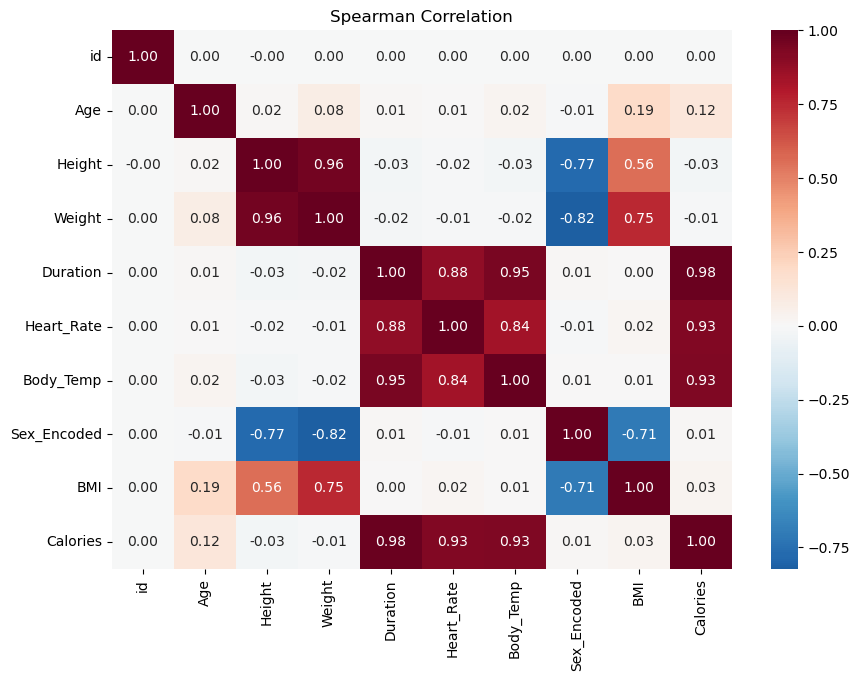

In [15]:
## Train Correlation

num_cols = train.select_dtypes(include = ["int64", "float64"]).columns.tolist()
num_cols.remove("Calories")

corr = train[num_cols + ["Calories"]].corr(method="spearman")

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Spearman Correlation")
plt.show()

In [16]:
## Splitting Data

X = train[['Sex_Encoded', 'Age', 'BMI', 'Duration', 'Heart_Rate', 'Body_Temp']]
y = train['Calories']


In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [32]:
## Model Hyperparameters

def rmsle(y_true, y_pred):
    y_pred = np.maximum(0, y_pred)
    return np.sqrt(mean_squared_log_error(y_true, y_pred))

def objective(trial):
    
    n_estimators = trial.suggest_int('n_estimators', 50, 500)
    max_depth = trial.suggest_int('max_depth', 3, 30)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)
    min_child_weight = trial.suggest_int('min_child_weight', 1, 20)
    subsample = trial.suggest_float('subsample', 0.5, 1.0)
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0)
    gamma = trial.suggest_float('gamma', 0, 5)
    reg_alpha = trial.suggest_float('reg_alpha', 0, 1)
    reg_lambda = trial.suggest_float('reg_lambda', 1, 2)

    model = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        min_child_weight=min_child_weight,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        gamma=gamma,
        reg_alpha=reg_alpha,
        reg_lambda=reg_lambda,
        random_state=42
    )


    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    score = rmsle(y_test, preds)
    return score  

In [33]:
## Optuna Optimization

study = optuna.create_study(direction='minimize')

study.optimize(objective, n_trials=50)

print("Best hyperparameters:", study.best_params)
print("Best RMSLE:", study.best_value)

[I 2025-05-13 14:36:36,425] A new study created in memory with name: no-name-83957ce1-052d-4037-960c-a9bfab29546d
[I 2025-05-13 14:36:39,006] Trial 0 finished with value: 0.09119825412903391 and parameters: {'n_estimators': 92, 'max_depth': 14, 'learning_rate': 0.05042711258149003, 'min_child_weight': 6, 'subsample': 0.5081814823853914, 'colsample_bytree': 0.6411085001395992, 'gamma': 3.1768209633388054, 'reg_alpha': 0.5002677620878775, 'reg_lambda': 1.2431242234934294}. Best is trial 0 with value: 0.09119825412903391.
[I 2025-05-13 14:36:55,522] Trial 1 finished with value: 0.0722787576567659 and parameters: {'n_estimators': 427, 'max_depth': 19, 'learning_rate': 0.03389982167452299, 'min_child_weight': 13, 'subsample': 0.5282413646853383, 'colsample_bytree': 0.6026580402566247, 'gamma': 2.650662147724743, 'reg_alpha': 0.025248658422256542, 'reg_lambda': 1.6459547719759282}. Best is trial 1 with value: 0.0722787576567659.
[I 2025-05-13 14:37:12,477] Trial 2 finished with value: 0.1670

Best hyperparameters: {'n_estimators': 396, 'max_depth': 11, 'learning_rate': 0.041900394898284406, 'min_child_weight': 20, 'subsample': 0.7471374312541288, 'colsample_bytree': 0.9008337439100882, 'gamma': 3.1744190951472744, 'reg_alpha': 0.2655739828198868, 'reg_lambda': 1.373382222253908}
Best RMSLE: 0.0636145612702887


In [35]:
## Optimized Model

opt_xgb_model = xgb.XGBRegressor(n_estimators=396, max_depth=11, learning_rate=0.041900394898284406, min_child_weight=20, subsample=0.7471374312541288, colsample_bytree=0.9008337439100882, gamma=3.1744190951472744, reg_alpha=0.2655739828198868, reg_lambda=1.373382222253908, random_state=42)

nonOP_xgb_model = xgb.XGBRegressor(random_state=42)

In [36]:
## Fitting Model

opt_xgb_model.fit(X_train, y_train)

nonOP_xgb_model.fit(X_train, y_train) 

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [37]:
## Make Predictions

train_predictions = opt_xgb_model.predict(X_test)

nonOP_train_predictions = nonOP_xgb_model.predict(X_test)

In [28]:
nonOP_train_predictions = np.maximum(0, nonOP_train_predictions)

In [38]:
## Root Mean Squared Logarithmic Error

msle = mean_squared_log_error(y_test, train_predictions)

rmsle = np.sqrt(msle)

print("RMSLE:", rmsle)

nonOP_msle = mean_squared_log_error(y_test, nonOP_train_predictions)

nonOP_rmsle = np.sqrt(nonOP_msle)

print("NON Optimized RMSLE:", nonOP_rmsle)

RMSLE: 0.0636145612702887
NON Optimized RMSLE: 0.0690641109406882
